## Notebook Order of Process

This notebook follows the methodological order of a machine learning workflow:

1. Identifying the Prediction Target  
2. Data Loading and Exploration  
3. Data Splitting  
4. Managing Missing Values  
5. Encoding Categorical Variables  
6. Feature Scaling  
7. Feature Selection  
8. Addressing Class Imbalance  
9. Training a Logistic Regression Model  
10. Task Ordering Justification

This order is chosen to prevent data leakage and to ensure that every transformation that learns from data is fitted on the training set only.

SWITCH TO SSH INSTEAD OF HTTPS

In [ ]:
### Reproducibility Note

All randomized operations in this notebook use `random_state=42` so that results are reproducible.

In [177]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

In [178]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 1. Identifying the Prediction Target

The objective of the marketing campaign is to determine whether a contacted client subscribes to a term deposit. Therefore, the appropriate prediction target is the variable **`y`**, which indicates whether the client subscribed to the product.

The variable `y` takes two possible values: **"yes"** and **"no"**, making this a **binary classification problem**. The goal of the machine learning model is to predict this outcome using the available information.

This variable directly reflects the business objective of the marketing campaign, which is to identify clients who are likely to subscribe to a term deposit so that the bank can target its marketing efforts more effectively.

In [180]:
print("Columns in the dataset:")
df.columns.tolist()

Columns in the dataset:


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [181]:
print("Target distribution:")
display(df["y"].value_counts())
display(df["y"].value_counts(normalize=True))

Target distribution:


y
no     3668
yes     451
Name: count, dtype: int64

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

### Why Other Variables Are Not Appropriate Prediction Targets

Some variables might superficially appear to be possible targets, but they do not correspond to the business objective of the campaign.

**duration**  
This variable represents the length of the phone call. Although it is often highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Since the model should make predictions using information available at the time of contact, including `duration` would introduce target leakage and artificially inflate model performance.

**campaign**  
This variable indicates how many contacts were performed during the current campaign for a client. It describes campaign activity rather than the actual outcome of interest.

For these reasons, the variable `y` is the correct prediction target for this assignment.

## 2. Data Loading and Exploration

Before performing any preprocessing or modeling, it is necessary to explore the dataset to understand its structure and characteristics.

This includes inspecting the number of observations, the number of features, the data types of variables, and the distribution of the target variable. In addition, we identify which variables are numerical and which are categorical, and we examine whether the dataset contains explicit or implicit missing values.

At this stage, the goal is descriptive analysis only. No transformation is fitted yet.

In [182]:
print("Dataset shape:", df.shape)
print("\nData types:")
display(df.dtypes)

Dataset shape: (4119, 21)

Data types:


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [183]:
print("Numerical summary statistics:")
display(df.describe())

print("Categorical summary statistics:")
display(df.describe(include="object"))

Numerical summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Categorical summary statistics:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [184]:
numerical_cols_full = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_full = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical variables:")
print(numerical_cols_full)

print("\nCategorical variables:")
print(categorical_cols_full)

Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset contains both numerical and categorical variables.

- Numerical variables include demographic, campaign, and macroeconomic information such as `age`, `campaign`, `pdays`, `euribor3m`, and `nr.employed`.
- Categorical variables include attributes such as `job`, `marital`, `education`, `contact`, and `poutcome`.

Since Logistic Regression requires numerical input, the categorical variables will later need to be encoded before they can be used by a machine learning model.

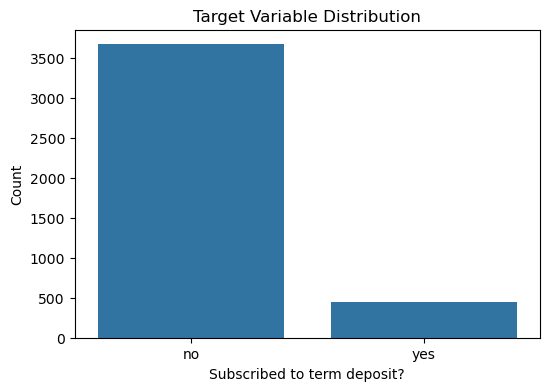

In [185]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to term deposit?")
plt.ylabel("Count")
plt.show()

### Interpretation of the Target Distribution

The dataset is strongly imbalanced. Most clients did **not** subscribe to a term deposit, while only a much smaller proportion did.

This matters because a naive classifier that always predicts the majority class could achieve high accuracy while still failing to identify likely subscribers. For that reason, later evaluation must not rely on accuracy alone.

In [191]:
print("Explicit missing values by column:")
display(df.isna().sum())

Explicit missing values by column:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

The raw dataset does not show conventional missing values in the form of `NaN` for most variables. However, this does not mean there is no missingness. Some missing information may appear implicitly through categories such as `"unknown"` or special numerical codes such as `pdays = 999`.

In [192]:
unknown_counts_full = {
    col: (df[col] == "unknown").sum()
    for col in categorical_cols_full
    if (df[col] == "unknown").any()
}

unknown_counts_full_df = (
    pd.DataFrame.from_dict(unknown_counts_full, orient="index", columns=["unknown_count"])
    .sort_values("unknown_count", ascending=False)
)

unknown_counts_full_df["unknown_percentage"] = unknown_counts_full_df["unknown_count"] / len(df) * 100
display(unknown_counts_full_df)

,unknown_count,unknown_percentage
default,803,19.495023
education,167,4.054382
housing,105,2.549162
loan,105,2.549162
job,39,0.946832
marital,11,0.267055


### Interpretation of Missingness in the Raw Dataset

The dataset contains almost no conventional missing values recorded as `NaN`. However, this does not mean the data is complete.

Several categorical variables contain the label `"unknown"`, which represents **implicit missingness**. This is important because missingness in this dataset is encoded partly through categories rather than through empty cells.

At this stage, I do not yet decide how to model this missingness. I only document that it exists and will need a principled treatment later.

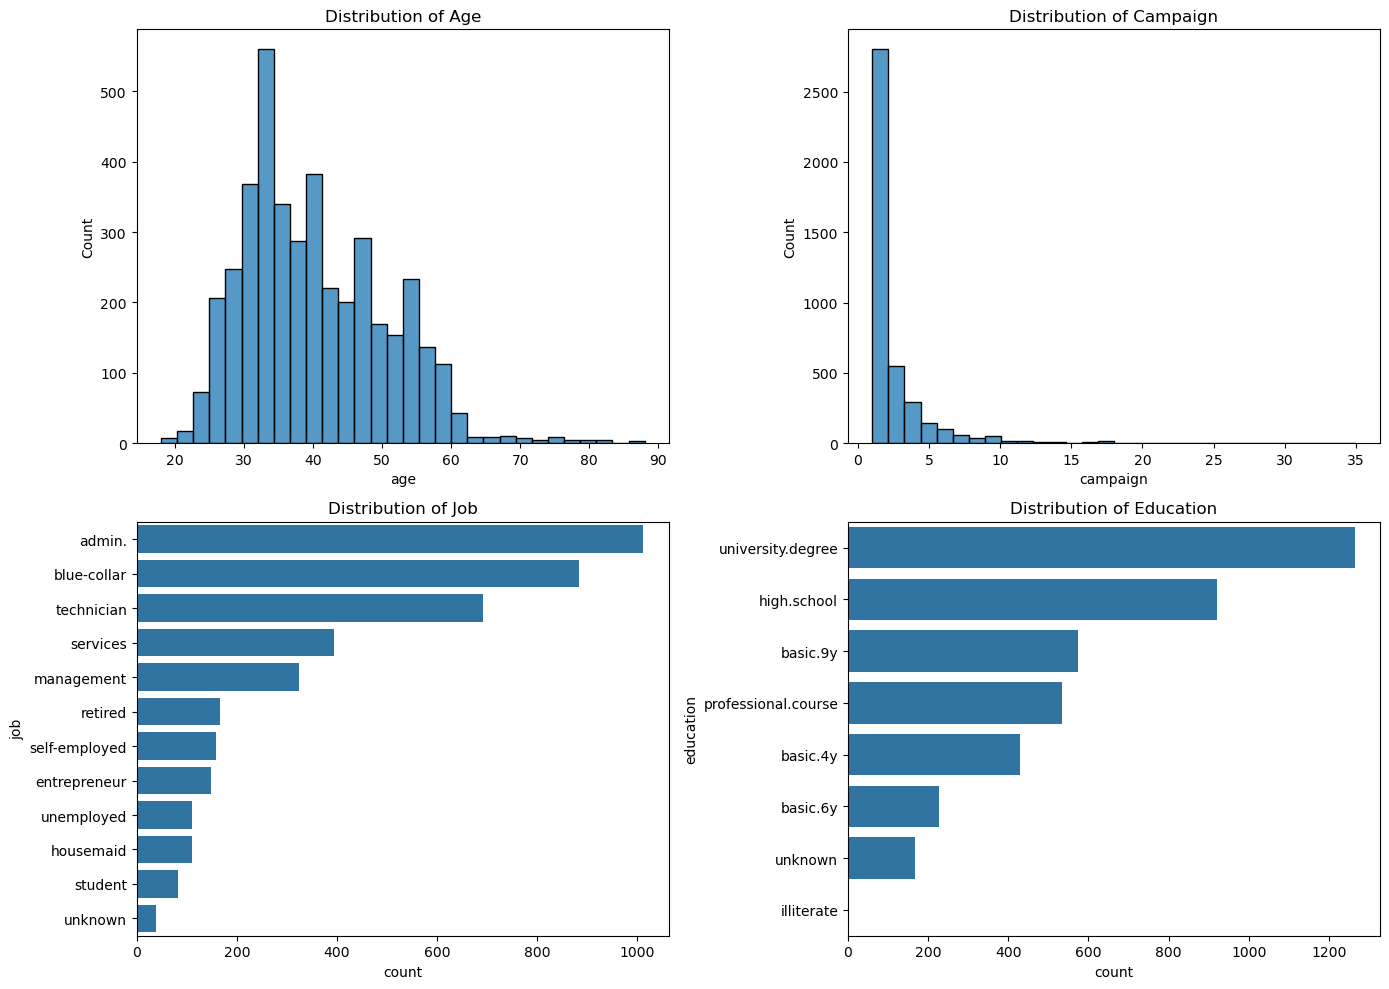

In [193]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["age"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Age")

sns.histplot(df["campaign"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Campaign")

job_order = df["job"].value_counts().index
sns.countplot(data=df, y="job", order=job_order, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Job")

education_order = df["education"].value_counts().index
sns.countplot(data=df, y="education", order=education_order, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Education")

plt.tight_layout()
plt.show()

### Interpretation of the Exploratory Visualizations

These plots support several important observations.

**Age**  
The age distribution is concentrated around adult and middle-aged clients, with fewer very young and very old observations. This suggests that age is a useful numerical predictor, but not one with extreme outliers dominating the sample.

**Campaign**  
The `campaign` variable is strongly right-skewed. Most clients were contacted only a small number of times, but a smaller set of clients were contacted many times. This skewness matters because it suggests that the variable is not symmetrically distributed and may influence a linear model differently from a roughly bell-shaped feature.

**Job and Education**  
Both variables contain multiple categories and cannot be passed directly to Logistic Regression. They will later require categorical encoding.

The visualizations are therefore not just descriptive. They directly motivate later steps involving encoding, scaling, and careful feature interpretation.

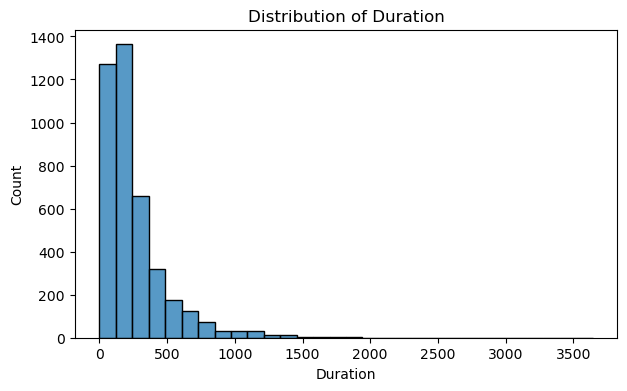

In [194]:
plt.figure(figsize=(7, 4))
sns.histplot(df["duration"], bins=30)
plt.title("Distribution of Duration")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

Although `duration` is visualized here to inspect its distribution, its main importance is conceptual rather than statistical. It will later be excluded from the predictive pipeline because it is not available at the time the prediction should be made.

### Variables Requiring Special Consideration Before Modeling

Two variables stand out as requiring special care.

One variable that requires special consideration is **duration**, which represents the length of the phone call.

Although `duration` is visualized here to inspect its distribution, its main importance is conceptual rather than statistical. This variable is highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage. Therefore, it should not be used as a predictor in the model.

Another variable that requires attention is **pdays**, which indicates the number of days since the client was last contacted. The value 999 represents that the client was not previously contacted, which acts as a sentinel value rather than a true numerical measurement. This will require careful handling during preprocessing.

## 3. Data Splitting

Before performing imputation, encoding, scaling, resampling, or feature selection, the dataset must be split into training, validation, and test sets.

This is necessary because all later transformations that learn from data must be fitted using the training set only. If the split were performed later, information from the validation or test sets would leak into the preprocessing stage.

### Removing `duration` Before Splitting

The assignment defines the prediction problem as using information available **at the time of contact**. Since `duration` is only known after the call ends, it must be removed from the predictor set before building the pipeline.

This is not a statistical feature selection decision. It is a **prediction-time validity** decision (a conceptual feature exclusion decision).

In [195]:
X = df.drop(columns=["y", "duration"]).copy()
y = df["y"].copy()

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (4119, 19)
Target vector shape: (4119,)


The dataset is split into three parts:

- **Training set**: used to fit preprocessing transformations and train the model
- **Validation set**: used to evaluate model performance and guide model decisions
- **Test set**: used for final evaluation after the pipeline has been developed

To preserve the class distribution of the target variable (because the target is imbalanced), **stratified sampling** is used with respect to the target variable `y`.

In [196]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2883, 19)
Validation set shape: (618, 19)
Test set shape: (618, 19)


In [197]:
print("Training target distribution:")
display(y_train.value_counts(normalize=True))

print("Validation target distribution:")
display(y_val.value_counts(normalize=True))

print("Test target distribution:")
display(y_test.value_counts(normalize=True))

Training target distribution:


y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation target distribution:


y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test target distribution:


y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64

In [198]:
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (2883, 19)
Validation set size: (618, 19)
Test set size: (618, 19)


A **70% / 15% / 15%** split is used. (training, validation, test)

Stratified splitting ensures that the proportion of clients who subscribed to a term deposit is approximately the same across the training, validation, and test sets.

This is important because the dataset exhibits class imbalance. Without stratification, one subset could contain a much higher or lower proportion of positive outcomes, which would lead to unreliable model evaluation.

If the dataset were split **after** preprocessing transformations such as scaling, encoding, or resampling, information from the validation or test sets could influence those transformations. This would lead to **data leakage**, producing overly optimistic model performance estimates. By splitting the dataset first, we ensure that all subsequent preprocessing steps are fitted using only the training data.

## 4. Managing Missing Values

Before applying machine learning models, it is necessary to identify and properly handle missing data. Missing values can appear either explicitly (for example as `NaN`) or implicitly through missing values encoded as `"unknown"` or sentinel numerical values such as `pdays = 999`.

These cases must be distinguished carefully because they do not all carry the same meaning.

Explicit missing values can be detected directly through the dataset, while implicit missing values require examining the meaning of categories and special numeric values.

All preprocessing decisions must be based only on the **training set** in order to avoid data leakage.

In [165]:
categorical_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols_train = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns in X_train:")
print(categorical_cols_train)

print("\nNumerical columns in X_train:")
print(numerical_cols_train)

Categorical columns in X_train:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns in X_train:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [199]:
missing_rows = []

for col in X_train.columns:
    explicit_na = X_train[col].isna().sum()
    implicit_unknown = (X_train[col] == "unknown").sum() if X_train[col].dtype == "object" else 0
    sentinel_999 = (X_train[col] == 999).sum() if col == "pdays" else 0

    if explicit_na > 0 or implicit_unknown > 0 or sentinel_999 > 0:
        missing_rows.append({
            "variable": col,
            "explicit_NaN_count": explicit_na,
            "explicit_NaN_pct": explicit_na / len(X_train) * 100,
            "unknown_count": implicit_unknown,
            "unknown_pct": implicit_unknown / len(X_train) * 100,
            "sentinel_999_count": sentinel_999,
            "sentinel_999_pct": sentinel_999 / len(X_train) * 100
        })

missing_summary_train = pd.DataFrame(missing_rows).sort_values(
    ["unknown_count", "sentinel_999_count", "explicit_NaN_count"], ascending=False
)

display(missing_summary_train)

,variable,explicit_NaN_count,explicit_NaN_pct,unknown_count,unknown_pct,sentinel_999_count,sentinel_999_pct
3,default,0,0.0,577,20.013874,0,0.000000
2,education,0,0.0,112,3.884842,0,0.000000
4,housing,0,0.0,65,2.254596,0,0.000000
5,loan,0,0.0,65,2.254596,0,0.000000
0,job,0,0.0,25,0.867152,0,0.000000
1,marital,0,0.0,7,0.242803,0,0.000000
6,pdays,0,0.0,0,0.000000,2764,95.872355


The dataset does not contain explicit missing values represented as `NaN`. However, several categorical variables include the category `"unknown"`, which likely represents missing or unavailable information.

Several categorical variables contain the category `"unknown"`. This category likely represents cases where the information about the client was not recorded or available. These values can therefore be interpreted as **implicit missing values**.

Rather than removing these observations, `"unknown"` will be treated as a valid category because it may contain useful information about the client or the data collection process.

In [167]:
print("Most common values of pdays in the training set:")
display(X_train["pdays"].value_counts().head(10))

Most common values of pdays in the training set:


pdays
999    2764
3        41
6        30
4        11
7         7
10        6
12        5
2         3
1         2
13        2
Name: count, dtype: int64

The variable `pdays` represents the number of days since the client was last contacted during a previous campaign. The value `999` indicates that the client was not previously contacted.

Therefore, `999` does not represent a real number of days but rather a special code indicating the absence of previous contact. This acts as a **sentinel value** rather than a genuine measurement.

During preprocessing, this value will require special treatment so that it does not distort the interpretation of the variable.

In [169]:
for dataset in [X_train, X_val, X_test]:
    dataset["previously_contacted"] = (dataset["pdays"] != 999).astype(int)
    dataset["pdays"] = dataset["pdays"].replace(999, np.nan)

In [170]:
print("Updated pdays summary in the training set:")
display(X_train["pdays"].describe())

print("Distribution of previously_contacted:")
display(X_train["previously_contacted"].value_counts(normalize=True))

Updated pdays summary in the training set:


count    119.000000
mean       5.806723
std        3.925746
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       19.000000
Name: pdays, dtype: float64

Distribution of previously_contacted:


previously_contacted
1    1.0
Name: proportion, dtype: float64

This treatment separates two different pieces of information:

- whether prior contact existed at all
- how many days have passed since that prior contact, when such contact exists

This is more principled than leaving `999` as a raw number, because treating it as a genuine numeric value would distort scaling and coefficient interpretation.

The strategy for handling missing values is therefore:

• Explicit missing values (`NaN`): none detected in this dataset.

• Implicit missing values (`"unknown"` categories): retained as valid categories, since they may carry predictive information.

• Sentinel value in `pdays` (`999`): treated as a special case representing no previous contact rather than a true numerical measurement.

All preprocessing transformations such as imputation will be fitted **only on the training set**, and then applied to the validation and test sets to prevent data leakage.

## 6. Encoding Categorical Variables

Machine learning models such as Logistic Regression require numerical input features. However, several variables in this dataset are categorical, meaning they represent qualitative categories rather than numeric quantities.

These categorical variables must therefore be encoded into numerical representations before the model can use them. The choice of encoding method depends on the nature of the categorical variable and the assumptions of the learning algorithm.

Categorical variables can be classified as either **nominal** or **ordinal**.

• **Nominal variables** represent categories without an intrinsic order. Examples include job type, marital status, and contact method.

• **Ordinal variables** represent categories that have a natural ordering. In this dataset, the variable `education` can be considered ordinal because education levels follow a progression from lower to higher levels of education.

For nominal variables, assigning arbitrary numerical labels could introduce artificial relationships between categories. Therefore, one-hot encoding is preferred.

### Encoding Strategy

For this dataset, **one-hot encoding** is used for categorical variables. One-hot encoding creates a binary indicator variable for each category, allowing the model to represent each category independently.

This approach is particularly appropriate for Logistic Regression because it allows the model to assign separate coefficients to each category without imposing an artificial ordering.

In [171]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()

encoder_demo = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
encoder_demo.fit(X_train[categorical_cols_train])

encoded_feature_names = encoder_demo.get_feature_names_out(categorical_cols_train)

print("Number of encoded categorical features:", len(encoded_feature_names))
print("First 20 encoded feature names:")
print(encoded_feature_names[:20])

Number of encoded categorical features: 43
First 20 encoded feature names:
['job_blue-collar' 'job_entrepreneur' 'job_housemaid' 'job_management'
 'job_retired' 'job_self-employed' 'job_services' 'job_student'
 'job_technician' 'job_unemployed' 'job_unknown' 'marital_married'
 'marital_single' 'marital_unknown' 'education_basic.6y'
 'education_basic.9y' 'education_high.school' 'education_illiterate'
 'education_professional.course' 'education_university.degree']


One-hot encoding increases the dimensionality of the dataset because each categorical variable is expanded into multiple binary features, one for each category.

For example, a variable with five possible categories will produce five binary columns after encoding. This increases the number of input features used by the model.

However, this representation allows Logistic Regression to learn separate coefficients for each category, improving interpretability and flexibility of the model.

The encoder is fitted **only on the training data**. This ensures that information from the validation or test sets does not influence the encoding process. If the encoder were fitted using the entire dataset, it could introduce data leakage by incorporating information about categories that appear only in the validation or test sets.

## 7. Feature Scaling

Numerical variables in the dataset operate on very different scales. For example, `age`, `campaign`, `euribor3m`, and `nr.employed` have very different units and ranges.

Feature scaling affects Logistic Regression in several ways:

• **Gradient-based optimization:** When features have very different scales, gradient descent may converge slowly or become unstable.

• **Coefficient comparability:** Without scaling, the magnitude of coefficients depends on the units of the features rather than their relative importance.

• **Regularization penalties:** Regularization terms such as L2 penalties operate on the magnitude of coefficients. If features are not scaled, the regularization effect may disproportionately penalize some variables.

The scaler is fitted only on the training set to prevent data leakage. If scaling parameters were computed using the full dataset, information from the validation and test sets could influence the preprocessing stage, leading to overly optimistic evaluation results.

In [172]:
numerical_cols_train = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

scaler_demo = StandardScaler()
X_train_scaled_demo = scaler_demo.fit_transform(X_train[numerical_cols_train])

X_train_scaled_demo_df = pd.DataFrame(
    X_train_scaled_demo,
    columns=numerical_cols_train,
    index=X_train.index
)

display(X_train_scaled_demo_df.head())

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
1948,0.849392,2.080561,NaN,-0.357112,0.848208,-0.233416,0.937292,0.779757,0.842054,0.0
2198,0.366946,-0.209287,NaN,-0.357112,0.848208,0.576339,-0.488655,0.778029,0.842054,0.0
166,-0.790923,-0.209287,NaN,-0.357112,-1.197978,-1.174714,-1.244839,-1.324662,-0.900585,0.0
2152,0.366946,-0.590929,NaN,-0.357112,-0.110942,-0.650252,-0.337418,0.311404,0.405719,0.0
2881,-0.694434,-0.590929,NaN,-0.357112,-1.197978,-1.174714,-1.244839,-1.306804,-0.900585,0.0


In the final preprocessing pipeline, this scaling transformation will be fitted using training-set statistics only, then applied unchanged to the validation and test sets.

Standardization transforms each numerical feature so that it has a mean of zero and a standard deviation of one.

This transformation is computed using statistics from the **training set only**, and the same transformation is later applied to the validation and test sets.

By scaling features in this way, the optimization algorithm used by Logistic Regression converges more efficiently and the learned coefficients become more comparable across variables.

## 7. Feature Selection

Feature selection aims to remove features that provide little useful information for the model or that may introduce instability in the estimation process.

Removing unnecessary or redundant variables can improve model interpretability and reduce noise in the learning process. Feature selection should be performed carefully to avoid removing variables that may contain useful predictive information.

All feature selection decisions are based **only on the training set** to prevent data leakage.

In [173]:
variance_values = X_train[numerical_cols_train].var().sort_values()
display(variance_values)

previously_contacted       0.000000
previous                   0.314198
cons.price.idx             0.342768
emp.var.rate               2.446584
euribor3m                  3.014293
campaign                   6.868147
pdays                     15.411480
cons.conf.idx             21.430475
age                      107.446945
nr.employed             5481.697956
dtype: float64

I use a conservative low-variance criterion. In this dataset, no numerical variable has zero variance, so no feature is removed on that basis. This demonstrates the correct methodological check without forcing arbitrary pruning.

Features with extremely low variance provide little information for distinguishing between observations because their values remain almost constant across the dataset.

In this dataset, no numerical variables exhibit zero variance, so no features are removed based solely on variance.

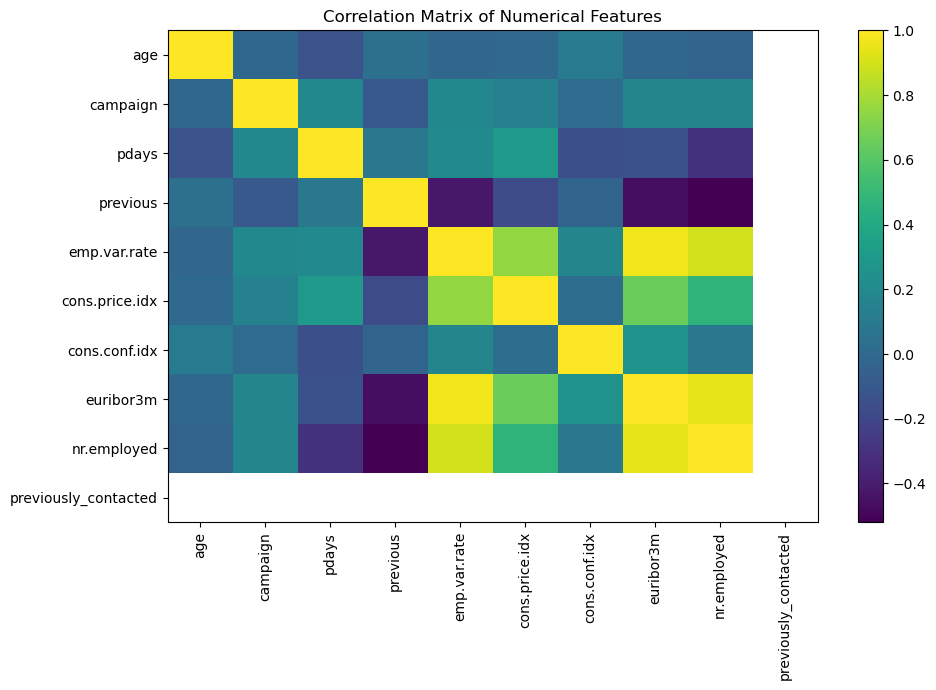

In [174]:
corr_matrix = X_train[numerical_cols_train].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Numerical Features")
plt.colorbar()
plt.tight_layout()
plt.show()

The correlation analysis shows that some macroeconomic variables are strongly correlated. This is expected because they reflect related aspects of the same economic environment.

For this assignment, I make a conservative choice and do not automatically remove correlated macroeconomic variables solely on the basis of pairwise correlation. Instead, I document the potential multicollinearity risk and prioritize the more important conceptual exclusion of leaked features such as `duration`.

Feature selection must be based on the training set only. If the full dataset were used to decide which features to keep, the validation and test sets would indirectly influence model design, creating leakage.

In [131]:
if "duration" in X_train.columns:
    X_train = X_train.drop(columns=["duration"])
    X_val = X_val.drop(columns=["duration"])
    X_test = X_test.drop(columns=["duration"])

In [137]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

Feature selection must be performed using only the training data. If feature selection were performed using the entire dataset before splitting, information from the validation and test sets could influence which features are retained.

This would introduce data leakage and lead to overly optimistic model performance estimates. By basing feature selection decisions only on the training set, we ensure that the evaluation process remains unbiased.

## 8. Addressing Class Imbalance

Class imbalance occurs when one class in the target variable appears much more frequently than the other. In this dataset, most clients did not subscribe to the term deposit, while a much smaller proportion did.

Class imbalance can affect the performance of machine learning models because the model may become biased toward predicting the majority class. This can lead to misleading evaluation metrics such as high accuracy but poor detection of the minority class.

In [ ]:
y_train.value_counts()

In [ ]:
y_train.value_counts(normalize=True)

The distribution of the target variable shows a strong imbalance between the classes. The majority of observations correspond to clients who did not subscribe to a term deposit, while a much smaller proportion corresponds to clients who did subscribe.

If this imbalance is not addressed, a model could achieve high accuracy simply by predicting the majority class for most observations.

For example, if 90% of clients do not subscribe to a term deposit, a naive classifier that always predicts "no" would achieve 90% accuracy. However, such a model would fail to identify clients who are likely to subscribe, which is the primary objective of the marketing campaign.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [ ]:
y_train_resampled.value_counts()

Random oversampling increases the number of observations in the minority class by duplicating existing examples. This creates a more balanced dataset, allowing the model to learn patterns associated with the minority class more effectively.

This method was chosen because it is simple and does not introduce synthetic observations, which may be harder to interpret.

Resampling must be applied **only to the training set**. The validation and test sets must preserve the original class distribution so that model evaluation reflects real-world conditions.

If resampling were applied before splitting the dataset, duplicated or synthetic observations could appear in both the training and validation sets. This would introduce data leakage and lead to overly optimistic performance estimates.

Class imbalance affects evaluation metrics in different ways:

• **Accuracy** may appear high even if the model performs poorly on the minority class.

• **Precision** measures how many predicted positive cases are actually correct.

• **Recall** measures how many of the true positive cases are correctly identified by the model.

Because the marketing objective is to identify potential subscribers, recall for the positive class becomes particularly important.

## 9. Training a Logistic Regression Model

After completing the data preparation steps, a Logistic Regression model is trained as a sanity check to verify that the preprocessing pipeline is coherent.

The objective of this step is not to optimize predictive performance but to confirm that the prepared dataset can be used to train a reasonable model.